# Trabalho Prático 02 - K-Means
**Base de dados:** Iris Dataset

## Etapa 1: Preparação e Limpeza dos Dados
Nesta primeira etapa, vamos preparar nossos dados para o algoritmo K-Means. Como se trata de um método de aprendizado não supervisionado, é fundamental removermos qualquer rótulo ou identificador prévio (como as colunas `Id` e `Species`) da entrada do modelo. As espécies reais serão guardadas apenas para análise posterior.

Além disso, aplicaremos a **Padronização (Z-Scoring)**. Esse processo centraliza cada variável em relação à média e a normaliza pelo desvio padrão. Isso garante que atributos com escalas diferentes não afetem negativamente o cálculo das distâncias matemáticas que o K-Means utiliza para formar os agrupamentos.

In [7]:
# Importando as bibliotecas necessárias
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Carregando a base de dados
# Certifique-se de que o arquivo 'Iris.csv' está na mesma pasta do seu Jupyter Notebook
df = pd.read_csv("Iris.csv")

# 2. Separando os atributos numéricos (X) dos rótulos
# O K-Means usará apenas as medidas das pétalas e sépalas
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

# Guardamos os rótulos reais apenas para conferência futura
rotulos_reais = df['Species'] 

# 3. Aplicando a Padronização (Z-Scoring)
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

# Visualizando o resultado da primeira flor antes e depois
print("Valores originais da 1ª flor:\n", X.iloc[0].values)
print("\nValores padronizados da 1ª flor:\n", X_padronizado[0])

Valores originais da 1ª flor:
 [5.1 3.5 1.4 0.2]

Valores padronizados da 1ª flor:
 [-0.90068117  1.03205722 -1.3412724  -1.31297673]


## Etapa 2: Escolhendo o valor de K (Método do Cotovelo)
O algoritmo K-Means exige que o número de clusters ($K$) seja definido antes da execução. Para não escolhermos esse número de forma arbitrária, utilizaremos o **Método do Cotovelo (Elbow Method)** e a métrica de **Inércia (WCSS - Within-Cluster Sum of Squares)**. 

A Inércia mede o quão compactos estão os grupos (quanto menor, mais próximos os pontos estão de seus respectivos centroides). Executaremos o K-Means para vários valores de $K$ (de 1 a 10) e plotaremos a Inércia. O ponto ideal é o "cotovelo" do gráfico, onde a queda na Inércia deixa de ser acentuada, indicando que adicionar mais clusters não traz um ganho significativo na compactação.

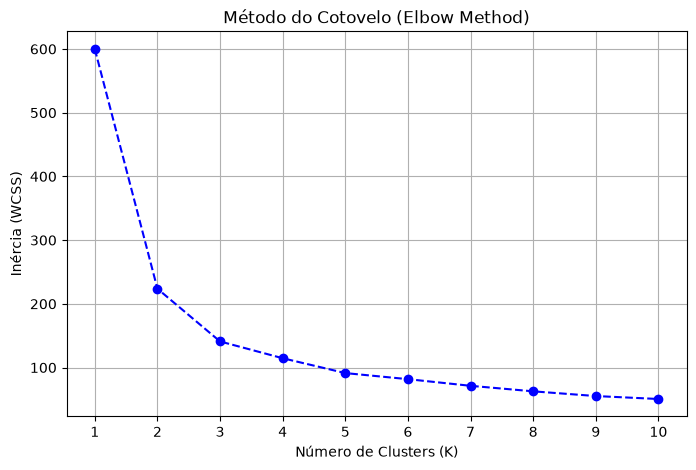

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Lista para guardar os valores de Inércia (WCSS)
wcss = []

# Testando valores de K de 1 a 10
valores_k = range(1, 11)

for k in valores_k:
    # random_state=42 garante que o resultado seja o mesmo toda vez que rodar
    # n_init=10 executa o algoritmo 10 vezes com centros iniciais diferentes e escolhe o melhor
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_padronizado)
    
    # kmeans.inertia_ retorna o valor do WCSS para aquele K
    wcss.append(kmeans.inertia_)

# Plotando o gráfico do Método do Cotovelo
plt.figure(figsize=(8, 5))
plt.plot(valores_k, wcss, marker='o', linestyle='--', color='b')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.xticks(valores_k)
plt.grid(True)
plt.show()